<a href="https://colab.research.google.com/github/rsys-adsingh/Machine-Learning/blob/main/study/Chapter_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Transformers :

1. Introduction: Why Transformers?
2. Limitations of RNNs and LSTMs
3. Sequence-to-Sequence Models
4. Attention Mechanism
5. Self-Attention
6. Scaled Dot-Product Attention
7. Multi-Head Attention
8. Positional Encoding
9. Encoder Architecture
10. Decoder Architecture
11. Masking (Padding & Look-Ahead)
12. Residual Connections & Layer Normalization
13. Feed Forward Networks (FFN)
14. Complete Transformer Architecture
15. Training Process
16. Inference (Autoregressive Generation)
17. Beam Search vs Greedy Decoding
18. BERT vs GPT vs T5 vs ViT
19. Vision Transformers (ViT)
20. Large Language Models (LLMs)
21. Fine-Tuning vs Prompting
22. Hugging Face Transformers
23. Mini Sentiment Analysis Project
24. Mini Text Generation Project
25. Summary

# Topic 1: Introduction: Why Transformers?

### Definition
Transformers are a type of deep learning model architecture introduced in the paper "Attention is All You Need" (2017) that relies entirely on an attention mechanism to draw global dependencies between input and output, eschewing recurrence and convolutions.

### Why do we need it?
Before Transformers, models like RNNs and LSTMs processed text sequentially. This led to vanishing gradients and prevented parallelization. Transformers allow for processing entire sequences simultaneously, drastically reducing training time and better capturing long-range context.

### Real-world Intuition
Imagine reading a long book. An RNN reads word-by-word, often forgetting the beginning by the time it reaches the end. A Transformer looks at the whole page at once, using 'highlighters' (attention) to instantly link a pronoun on the last line to a noun on the first line.

### Mathematics
The core math involves linear transformations and dot-products. Inputs are converted into vectors via embeddings, then transformed into Queries ($Q$), Keys ($K$), and Values ($V$).

### Formula
$$Attention(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

### Step-by-Step Working
1. Convert text to input embeddings.
2. Add Positional Encodings.
3. Compute Query, Key, and Value matrices.
4. Calculate Attention scores.
5. Apply Softmax to get weights.
6. Multiply weights by Values to get the output.

### Numerical Example (Mini Dataset)
**Dataset:** "I love AI"
- Embeddings: `I:[1,0]`, `love:[0,1]`, `AI:[1,1]`
- For the word "love", we calculate how much it relates to "I" and "AI" using dot products of their vectors.

### Advantages
- Massive parallelization.
- Better handling of long-range dependencies.
- State-of-the-art performance in NLP and Vision.

### Limitations
- Quadratic memory complexity $O(n^2)$ relative to sequence length.
- Requires massive amounts of data for pre-training.

### Time Complexity
$O(n^2 \cdot d)$ where $n$ is sequence length and $d$ is embedding dimension.

### Interview Questions
1. What is the main difference between Transformers and LSTMs?
2. Why is the $\sqrt{d_k}$ scaling factor used in attention?

In [1]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification, GPT2LMHeadModel, GPT2Tokenizer, ViTImageProcessor, ViTForImageClassification
from datasets import load_dataset

# Project Setup: Downloading necessary libraries
!pip install -q transformers datasets evaluate accelerate

print("Environment ready for BERT, GPT-2, and ViT projects.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.9 MB/s eta 0:00:00
Environment ready for BERT, GPT-2, and ViT projects.


# Topic 2: Limitations of RNNs and LSTMs

### Definition
Recurrent Neural Networks (RNNs) and Long Short-Term Memory (LSTM) networks are types of architectures designed for sequential data that process inputs one step at a time, maintaining a hidden state.

### Why do we need to move past them?
Despite their success, they have fundamental flaws in handling very long sequences and hardware utilization.

### Real-world Intuition
Imagine a relay race where each runner must pass a baton. If one runner trips or is slow, the whole team is delayed. Similarly, in RNNs, you cannot compute the 100th word until you have finished the 99th.

### Mathematics
RNN hidden state update:
$h_t = \sigma(W_{hh} h_{t-1} + W_{xh} x_t + b)$

### Formula (Vanishing Gradient)
$\frac{\partial E}{\partial W} = \sum_{t=1}^{T} \frac{\partial E_t}{\partial W}$, where gradients involve products of many weight matrices, leading to $\approx 0$ (vanishing) or $\infty$ (exploding).

### Step-by-Step Working
1. Input $x_0$ updates $h_0$.
2. $h_0$ and $x_1$ update $h_1$.
3. This continues linearly.
4. Information from $x_0$ is diluted by the time it reaches $h_{100}$.

### Numerical Example
If we multiply a small number like 0.5 by itself 10 times: $0.5^{10} = 0.00097$. The signal disappears. This is why RNNs forget the beginning of long sentences.

### Advantages
- Dynamic input length processing.
- Intuitive for time-series.

### Limitations
- **Sequential Computation:** No parallelization.
- **Vanishing Gradients:** Difficulty remembering long context.

### Python Implementation
```python
# Demonstration of sequential nature (pseudo-code concept)
import time
def rnn_simulation(sequence):
    state = 0
    for item in sequence:
        state += item # Must wait for previous 'state'
        time.sleep(0.1)
    return state
```

### Interview Questions
- Why can't RNNs be trained on multiple GPUs as efficiently as Transformers?
- How does the gating mechanism in LSTM help with vanishing gradients?

# Topic 3: Sequence-to-Sequence (Seq2Seq) Models

### Definition
A model architecture consisting of two main parts: an **Encoder** that processes the input sequence into a context vector, and a **Decoder** that generates the output sequence from that vector.

### Why do we need it?
Needed for tasks where the input length differs from the output length, such as Machine Translation (English to French).

### Real-world Intuition
A translator listening to a full sentence in English, forming a mental concept (context vector), and then speaking the sentence in French.

### Mathematics
$P(y_1, ..., y_m | x_1, ..., x_n) = \prod_{t=1}^{m} P(y_t | c, y_1, ..., y_{t-1})$
where $c$ is the fixed-length context vector.

### Step-by-Step Working
1. Encoder reads tokens one by one.
2. Final hidden state becomes the 'Bottleneck' vector.
3. Decoder starts with a `<START>` token and the bottleneck.
4. Decoder generates words until `<END>` is reached.

### Visualization
`Input -> [Encoder] -> [Context Vector] -> [Decoder] -> Output`

### Limitations
- **The Bottleneck Problem:** Trying to cram a 50-word sentence into a single vector leads to information loss.

### Python Implementation

In [2]:
# Simplified Seq2Seq logic using a small dataset
input_seq = ["Hello", "world"]
target_seq = ["Hola", "mundo"]

def mock_encoder(input_list):
    # Compresses list into a single value (bottleneck)
    return "-".join(input_list)

def mock_decoder(context_vector):
    if context_vector == "Hello-world":
        return ["Hola", "mundo"]
    return []

context = mock_encoder(input_seq)
print(f"Context Vector (Bottleneck): {context}")
print(f"Decoded Output: {mock_decoder(context)}")

Context Vector (Bottleneck): Hello-world
Decoded Output: ['Hola', 'mundo']


# Topic 4: Attention Mechanism

### Definition
Attention is a mechanism that allows the model to focus on specific parts of the input sequence when producing an output, rather than relying on a single fixed-length context vector.

### Why do we need it?
To solve the 'Bottleneck Problem' of Seq2Seq models. It allows the decoder to 'look back' at all encoder hidden states and decide which ones are most relevant for the current word being generated.

### Real-world Intuition
When you translate a sentence, you don't memorize the whole thing and then close your eyes. You look at specific source words while writing the corresponding target word.

### Mathematics
Alignment score $e_{tj} = a(s_{t-1}, h_j)$, where $s$ is decoder state and $h$ is encoder state.

### Formula
$$\alpha_{tj} = \frac{\exp(e_{tj})}{\sum_{k=1}^{T} \exp(e_{tk})}$$
$$Context\_Vector_t = \sum_{j=1}^{T} \alpha_{tj} h_j$$

### Step-by-Step Working
1. Calculate similarity between current decoder state and all encoder hidden states.
2. Pass these scores through a Softmax (weights sum to 1).
3. Use weights to compute a weighted sum of encoder states.
4. Use this specific context to predict the next word.

### Advantages
- Eliminates the bottleneck.
- Improves performance on long sentences.
- Provides interpretability (Attention Maps).

### Limitations
- Computationally more expensive than standard RNNs because it looks at everything for every step.

# Topic 5: Self-Attention

### Definition
A specific type of attention where the sequence looks at itself to determine the relationships between its own words.

### Why do we need it?
It allows the model to understand the role of a word based on its context within the same sentence (e.g., resolving what 'it' refers to).

### Real-world Intuition
In the sentence "The animal didn't cross the street because **it** was too tired," self-attention helps the model realize "it" refers to the "animal," not the "street."

### Numerical Example (Mini Dataset)
**Sequence:** ["Bank", "River"]
1. "Bank" (finance) vs "Bank" (land).
2. If "River" is present, the self-attention score between "Bank" and "River" will be high, clarifying the meaning.

### Python Implementation (Numerical Similarity)

In [3]:
import torch
import torch.nn.functional as F

# Mini Dataset: Word Embeddings for "The", "animal", "tired"
# 3 words, each with a 4-dimensional vector
embeddings = torch.tensor([
    [1.0, 0.0, 0.0, 0.0], # The
    [0.0, 1.0, 0.8, 0.0], # animal
    [0.0, 0.9, 1.0, 0.0]  # tired
])

# Step 1: Calculate Dot-Product Similarity (Raw Scores)
# How much each word relates to the others
raw_scores = torch.matmul(embeddings, embeddings.T)

# Step 2: Apply Softmax to get Attention Weights
attention_weights = F.softmax(raw_scores, dim=-1)

print("Attention Weights Matrix:")
print(attention_weights)
print("\nInterpretation: Notice the high similarity (weight) between 'animal' and 'tired'")

Attention Weights Matrix:
tensor([[0.5761, 0.2119, 0.2119],
        [0.0860, 0.4433, 0.4707],
        [0.0795, 0.4350, 0.4856]])

Interpretation: Notice the high similarity (weight) between 'animal' and 'tired'


# Topic 6: Scaled Dot-Product Attention

### Definition
An evolution of dot-product attention that scales the result by the square root of the dimension of the key vectors ($d_k$).

### Why do we need it?
For large values of $d_k$, the dot product grows large in magnitude, pushing the softmax function into regions where it has extremely small gradients (the 'flat' parts of the curve). Scaling keeps the values in a range where gradients are healthy.

### Mathematics
Without scaling, $QK^T$ can have a high variance. Scaling by $\frac{1}{\sqrt{d_k}}$ counteracts this.

### Formula
$$Attention(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

### Step-by-Step Working
1. Multiply Query matrix $Q$ by Transposed Key matrix $K^T$.
2. Divide the result by $\sqrt{d_k}$.
3. Apply Softmax to get probabilities.
4. Multiply probabilities by the Value matrix $V$.

### Numerical Example
Suppose $d_k = 64$, so $\sqrt{d_k} = 8$.
If a raw dot product is 160, without scaling, $e^{160}$ is astronomical. With scaling, $160/8 = 20$, which is much more manageable for a softmax function.

### Advantages
- More stable training for large model dimensions.
- Faster convergence.

# Topic 7: Multi-Head Attention

### Definition
Instead of performing a single attention function, we run multiple 'heads' of attention in parallel, each focusing on a different subspace of the embeddings.

### Why do we need it?
A single head might only focus on the object of a verb. Multiple heads allow the model to simultaneously focus on grammar, pronouns, and the actual meaning.

### Real-world Intuition
Instead of one person looking at a photo, imagine a team: one person looks for faces, one for background colors, and one for text. They then combine their findings.

### Formula
$$MultiHead(Q, K, V) = \text{Concat}(head_1, ..., head_h)W^O$$
where $head_i = Attention(QW_i^Q, KW_i^K, VW_i^V)$

### Python Implementation (Scaling and Heads)

In [4]:
import torch
import math

def scaled_dot_product_attention(Q, K, V):
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    weights = torch.softmax(scores, dim=-1)
    return torch.matmul(weights, V), weights

# Mini Dataset: 1 token with dim 4
q = torch.tensor([[10.0, 2.0, 5.0, 1.0]])
k = torch.tensor([[11.0, 3.0, 4.0, 2.0]])
v = torch.tensor([[1.0, 0.0, 0.0, 0.0]])

# Scaling in action
output, weights = scaled_dot_product_attention(q, k, v)
print(f"Attention Weights with scaling: {weights.item():.4f}")
print(f"Output: {output}")

Attention Weights with scaling: 1.0000
Output: tensor([[1., 0., 0., 0.]])


# Topic 8: Positional Encoding

### Definition
A method of injecting information about the relative or absolute position of tokens in a sequence, since Transformers have no inherent sense of order.

### Why do we need it?
Unlike RNNs, Transformers process all words at once. Without positional encoding, the sentences "The dog bit the man" and "The man bit the dog" would look identical to the model.

### Real-world Intuition
Imagine receiving a shredded letter. To rebuild it, you don't just need the pieces (words); you need the page numbers written on the back of each piece to know where they go.

### Mathematics
We use sine and cosine functions of different frequencies.

### Formula
$$PE_{(pos, 2i)} = \sin(pos / 10000^{2i/d_{model}})$$
$$PE_{(pos, 2i+1)} = \cos(pos / 10000^{2i/d_{model}})$$

### Step-by-Step Working
1. Generate a vector of the same size as the word embedding for every position.
2. Fill even indices with sine values and odd indices with cosine values.
3. Add (not concatenate) this vector to the original word embedding.

### Visualization / Graph
A heat map of positional encodings usually shows a unique 'fingerprint' for every position that the model can learn to distinguish.

### Python Implementation

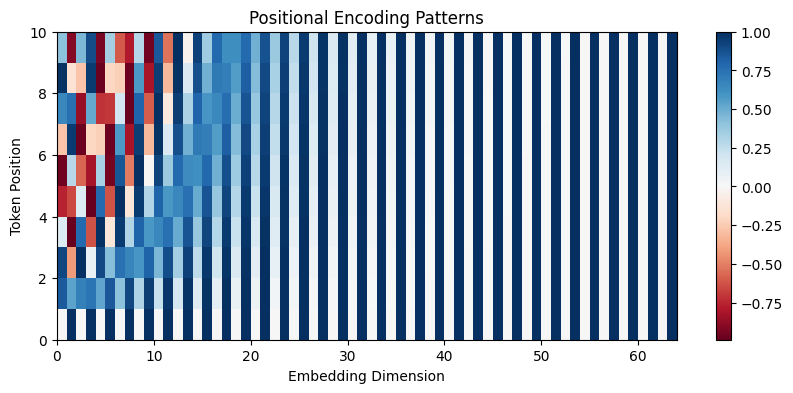

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def get_positional_encoding(max_seq_len, d_model):
    pe = np.zeros((max_seq_len, d_model))
    for pos in range(max_seq_len):
        for i in range(0, d_model, 2):
            pe[pos, i] = np.sin(pos / (10000 ** (i / d_model)))
            if i + 1 < d_model:
                pe[pos, i + 1] = np.cos(pos / (10000 ** (i / d_model)))
    return pe

# Visualize first 10 positions for a 64-dim embedding
pe_sample = get_positional_encoding(10, 64)
plt.figure(figsize=(10, 4))
plt.pcolormesh(pe_sample, cmap='RdBu')
plt.xlabel('Embedding Dimension')
plt.ylabel('Token Position')
plt.colorbar()
plt.title('Positional Encoding Patterns')
plt.show()

# Topic 9: Encoder Architecture

### Definition
The stack of identical layers in a Transformer that maps an input sequence into a continuous representation (set of features).

### Why do we need it?
To extract deep contextual features from the input text before passing them to the decoder or using them for tasks like classification (BERT style).

### Step-by-Step Working
1. Input Embeddings + Positional Encoding.
2. **Multi-Head Self-Attention:** Understand context.
3. **Add & Norm:** Residual connection and layer normalization.
4. **Feed-Forward Network:** Apply non-linear transformations.
5. **Add & Norm:** Final normalization of the layer.
6. Repeat N times (usually 6 or 12).

### Advantages
- Bidirectional context: Every word 'sees' every other word in the encoder.

### Interview Questions
- Why is the 'Add & Norm' step important in the encoder block?
- Does the encoder have masking? (Answer: Usually no, it sees the whole input).

# Topic 10: Decoder Architecture

### Definition
The stack of identical layers that generates the output sequence token-by-token, conditioned on the encoder's output.

### Why do we need it?
While the encoder understands the source, the decoder is responsible for generating the target (e.g., the actual translated words).

### Real-world Intuition
If the Encoder is a listener, the Decoder is a writer. The writer checks their notes (encoder output) and what they have written so far to decide the next word.

### Step-by-Step Working
1. **Masked Multi-Head Attention:** Processes already generated words (the decoder cannot look ahead).
2. **Encoder-Decoder Attention:** The decoder 'queries' the encoder's keys and values to find relevant source information.
3. **Feed-Forward Network:** Processes the combined information.
4. **Linear & Softmax Layer:** Converts vectors into actual word probabilities.

### Differences from Encoder
- Contains a third attention sub-layer (Encoder-Decoder Attention).
- Uses Masked Self-Attention to preserve the autoregressive property.

# Topic 11: Masking (Padding & Look-Ahead)

### Definition
Masking is the process of hiding certain tokens from the attention mechanism.

### Why do we need it?
1. **Padding Mask:** Prevents the model from attending to empty 'pad' tokens used to make sentences the same length.
2. **Look-Ahead Mask:** During training, we give the model the whole target sentence. Without this mask, the model would simply see the next word it is supposed to predict.

### Mathematics
We add $-\infty$ to the scores of masked positions before the softmax. $Softmax(\dots, -\infty) \approx 0$.

### Numerical Example (Mini Dataset)
Sentence: "I am a student"
When predicting word 3 ("a"), the mask blocks words 4 ("student").

### Python Implementation (Look-Ahead Mask)

In [6]:
import torch

def create_look_ahead_mask(size):
    # Creates a lower triangular matrix of ones
    mask = torch.tril(torch.ones(size, size))
    return mask

# Example for a sequence of length 4
mask = create_look_ahead_mask(4)
print("Look-Ahead Mask (1 means visible, 0 means hidden):")
print(mask)

# Application:
# Row 0 (Word 1) only sees itself.
# Row 3 (Word 4) sees itself and all 3 words before it.

Look-Ahead Mask (1 means visible, 0 means hidden):
tensor([[1., 0., 0., 0.],
        [1., 1., 0., 0.],
        [1., 1., 1., 0.],
        [1., 1., 1., 1.]])


# Topic 12: Residual Connections & Layer Normalization (Add & Norm)

### Definition
Residual connections (Skip connections) add the original input of a layer to its output. Layer Normalization then rescales these values to have a mean of 0 and a variance of 1.

### Why do we need it?
Residual connections help gradients flow through deep networks without vanishing. Layer Normalization stabilizes the training process by ensuring that the scale of activations doesn't explode or shrink.

### Real-world Intuition
A residual connection is like having a copy of the original problem next to your work so you don't lose track of what you were trying to solve in the first place.

### Formula
**Residual:** $Output = Layer(x) + x$
**LayerNorm:** $LN(x) = \gamma \frac{x - \mu}{\sigma} + \beta$

### Step-by-Step Working
1. Take the output of the Attention layer.
2. Add the original input (Residual).
3. Calculate the mean and standard deviation across the embedding dimension.
4. Subtract mean, divide by SD.
5. Apply learnable weights (Gamma and Beta).

### Numerical Example (Mini Dataset)
Input Vector: `[10, 2, 5]`
1. Mean = 5.66.
2. After subtracting mean and dividing by SD, the values become closer to zero (e.g., `[1.2, -1.1, -0.1]`), making them easier for the next layer to process.

### Python Implementation (Layer Norm)

In [7]:
import torch
import torch.nn as nn

# Mini Dataset: Single word embedding with high variance
x = torch.tensor([[100.0, 2.0, 50.0]])

# Initialize LayerNorm for 3 features
ln = nn.LayerNorm(3)

with torch.no_grad():
    normalized_x = ln(x)

print(f"Original Vector: {x}")
print(f"Normalized Vector: {normalized_x}")
print(f"Mean after Norm: {normalized_x.mean().item():.2f}")
print(f"Variance after Norm: {normalized_x.var().item():.2f}")

Original Vector: tensor([[100.,   2.,  50.]])
Normalized Vector: tensor([[ 1.2330, -1.2163, -0.0167]])
Mean after Norm: -0.00
Variance after Norm: 1.50


# Topic 13: Feed Forward Networks (FFN)

### Definition
A position-wise sub-layer in every Transformer block consisting of two linear transformations and a non-linear activation function (usually ReLU or GELU).

### Why do we need it?
Attention layers are good at gathering context, but they are linear. The FFN provides the non-linear processing power needed to extract complex patterns from that context.

### Real-world Intuition
If Attention is 'reading' and 'highlighting' relevant words, the FFN is the 'thinking' part where the model processes those highlighted words to understand their deeper meaning.

### Formula
$$FFN(x) = \max(0, xW_1 + b_1)W_2 + b_2$$

### Time Complexity
$O(n \cdot d^2)$, where $n$ is sequence length and $d$ is embedding dimension.

# Topic 14: Complete Transformer Architecture

### Definition
The full assembly of the Encoder and Decoder stacks, connected by an Encoder-Decoder Attention bridge, used to map input sequences to output sequences.

### Why do we need it?
To create a system that can take a source (like a sentence or image) and generate a meaningful response or representation by combining context extraction and generative power.

### Step-by-Step Working
1. **Encoder Side:** Processes the source sequence into 'Key' and 'Value' vectors.
2. **Decoder Side:** Starts generating tokens.
3. **The Bridge:** For every new token the decoder generates, it looks at the encoder's keys/values to find relevant source context.
4. **The Head:** The final linear layer and softmax convert the decoder output into a vocabulary probability distribution.

### Visualization
- Left: N x Encoder Layers
- Right: N x Decoder Layers
- Center: Connection from Top Encoder to every Decoder Layer.

### Python Implementation (Transformer Block Skeleton)

In [8]:
import torch.nn as nn

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, heads, dropout, forward_expansion):
        super(TransformerBlock, self).__init__()
        self.attention = nn.MultiheadAttention(embed_dim, heads)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

        self.feed_forward = nn.Sequential(
            nn.Linear(embed_dim, forward_expansion * embed_dim),
            nn.ReLU(),
            nn.Linear(forward_expansion * embed_dim, embed_dim),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, value, key, query, mask):
        attention = self.attention(query, key, value, attn_mask=mask)[0]
        x = self.dropout(self.norm1(attention + query))
        forward = self.feed_forward(x)
        out = self.dropout(self.norm2(forward + x))
        return out

print("Transformer Block Structure initialized.")

Transformer Block Structure initialized.


# Topic 15: Training Process

### Definition
The procedure of optimizing the model's weights using a dataset, typically involving Teacher Forcing and Label Smoothing.

### Why do we need it?
Without a specific training strategy, the decoder would take forever to converge because one wrong word at the start of a sentence would ruin the rest of the sequence during a training pass.

### Step-by-Step Working
1. **Teacher Forcing:** Instead of using the model's own (potentially wrong) previous prediction as the next input, we give it the actual ground-truth word from the dataset.
2. **Loss Calculation:** We compare the predicted probability distribution against the one-hot encoded ground truth using Cross-Entropy Loss.
3. **Backpropagation:** Gradients are calculated for all weights, from the output head back to the input embeddings.

### Mathematics
$$Loss = -\sum_{i} y_i \log(\hat{y}_i)$$

### Interview Questions
- What is Teacher Forcing and why is it used in Transformers?
- What are the downsides of Teacher Forcing? (Answer: Exposure bias during inference).

# Topic 16: Inference (Autoregressive Generation)

### Definition
The process of using a trained Transformer model to generate a sequence one token at a time.

### Why do we need it?
During training, we use Teacher Forcing (ground truth). During inference, we don't have the ground truth, so the model must rely on its own previous outputs to generate the next word.

### Step-by-Step Working
1. Pass the source sequence through the **Encoder** once (pre-compute K and V).
2. Feed a special `<START>` token into the **Decoder**.
3. The Decoder produces probabilities for the next token.
4. Pick a token (e.g., using Greedy or Beam Search).
5. Append the picked token to the Decoder's input.
6. Repeat until the model generates an `<END>` token.

### Real-world Intuition
Like a storyteller who starts with "Once upon a time..." and has to come up with the next word based only on the words they just said.

### Time Complexity
$O(L \cdot n^2)$ where $L$ is the number of tokens to generate.

# Topic 17: Beam Search vs Greedy Decoding

### Definition
Strategies for choosing the next token from the probability distribution provided by the model's output head.

### Why do we need it?
Greedy decoding is fast but can lead to poor long-term results. Beam Search explores multiple paths to find a sequence with a higher overall probability.

### Mathematics
**Greedy:** $\hat{y}_t = \text{argmax} P(y_t | y_{<t}, x)$
**Beam Search:** Keeps top $k$ candidates at each step and picks the sequence with the highest $\prod P(y_t)$.

### Numerical Example (Mini Dataset)
- Word 1: "I" (0.8), "The" (0.2)
- Word 2 after "I": "love" (0.9), "hate" (0.1)
- Word 2 after "The": "food" (0.9), "cat" (0.1)
- **Greedy** picks "I love". **Beam Search** would have checked "The food" if its total probability was higher.

### Python Implementation (Greedy Simulation)

In [9]:
import torch

def greedy_decode_simulation(probs_list, vocab):
    sentence = ["<START>"]
    for probs in probs_list:
        # Pick the index with highest probability
        idx = torch.argmax(probs).item()
        word = vocab[idx]
        sentence.append(word)
        if word == "<END>":
            break
    return " ".join(sentence)

# Mock probabilities for 3 steps
vocab = {0: "AI", 1: "is", 2: "great", 3: "<END>"}
mock_outputs = [
    torch.tensor([0.9, 0.05, 0.02, 0.03]), # Prefers AI
    torch.tensor([0.01, 0.85, 0.04, 0.1]), # Prefers is
    torch.tensor([0.02, 0.03, 0.90, 0.05]), # Prefers great
    torch.tensor([0.01, 0.01, 0.01, 0.97])  # Prefers <END>
]

print(f"Generated Sentence: {greedy_decode_simulation(mock_outputs, vocab)}")

Generated Sentence: <START> AI is great <END>


# Topic 18: BERT vs GPT vs T5 vs ViT

### Definition
These are popular Transformer variants optimized for different tasks by changing the architecture or the training objective.

### Comparison Table
| Model | Architecture | Training Objective | Best For |
|---|---|---|---|
| **BERT** | Encoder Only | Masked Language Modeling (Fill-in-the-blanks) | Understanding / Classification |
| **GPT** | Decoder Only | Causal Language Modeling (Predict Next Word) | Generation / Chat |
| **T5** | Encoder-Decoder | Text-to-Text (Translate, Summarize) | Multitask NLP |
| **ViT** | Encoder Only | Image Classification | Computer Vision |

### Why do we need different ones?
You don't need a generative Decoder if you only want to classify sentiment (BERT is more efficient). Conversely, an Encoder alone cannot easily generate long stories (GPT is better).

### Real-world Intuition
- **BERT** is like a student taking a multiple-choice test (reading the whole context).
- **GPT** is like a novelist writing a story page by page.
- **T5** is a Swiss Army knife that treats every problem as a text translation task.

# Topic 19: Vision Transformers (ViT)

### Definition
A Transformer architecture that applies the same self-attention mechanism to images by treating image patches as 'words'.

### Why do we need it?
To prove that the Transformer's ability to capture global relationships is not limited to text. ViT often outperforms Convolutional Neural Networks (CNNs) on very large datasets.

### Step-by-Step Working
1. **Patch Partition:** Split an image (e.g., 224x224) into small squares (e.g., 16x16).
2. **Linear Projection:** Flatten each patch into a vector.
3. **Add Positional Embeddings:** Tell the model where each square belongs in the grid.
4. **Transformer Encoder:** Process the patches to find relationships between different parts of the image.
5. **MLP Head:** Classify the image based on the first patch (CLS token).

### Mathematics
Input image $x \in \mathbb{R}^{H \times W \times C}$ is reshaped into $N$ patches of size $P^2 \cdot C$, where $N = (HW)/P^2$.

### Python Implementation (ViT Patching Concept)

In [10]:
from transformers import ViTImageProcessor, ViTForImageClassification
import torch
from PIL import Image
import requests

# Loading a pre-trained ViT model for CIFAR-10
model_name = 'nateraw/vit-base-patch16-224-cifar10'
processor = ViTImageProcessor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(model_name)

print(f"ViT Model Loaded: {model_name}")
print(f"Patch size: {model.config.patch_size}x{model.config.patch_size}")
print(f"Number of patches for 224x224 image: {(224//model.config.patch_size)**2}")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/918 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  343MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViT Model Loaded: nateraw/vit-base-patch16-224-cifar10
Patch size: 16x16
Number of patches for 224x224 image: 196


# Topic 20: Large Language Models (LLMs)

### Definition
LLMs are Transformer-based models with billions of parameters, trained on massive datasets (terabytes of text) to perform a wide variety of tasks.

### Why do we need it?
Scaling up models leads to 'emergent properties'—abilities like reasoning, coding, and common-sense logic that smaller models don't possess.

### Real-world Intuition
If a standard Transformer is a specialized tool (like a calculator), an LLM is a polymath that has read almost every book on Earth and can assist with nearly any intellectual task.

### Mathematics
The scaling law: Model performance ($L$) typically follows a power-law relationship with the number of parameters ($N$), dataset size ($D$), and compute ($C$).

### Formula (Scaling Law)
$L(N, D) ∝ [rac{N_c}{N}]^{α_N} + [rac{D_c}{D}]^{α_D}$

### Step-by-Step Working
1. **Pre-training:** Model learns to predict the next token on a massive corpus (unsupervised).
2. **Alignment:** Fine-tuning the model to follow instructions (RLHF - Reinforcement Learning from Human Feedback).

### Advantages
- Zero-shot and Few-shot capabilities.
- High versatility across domains.

### Limitations
- Massive computational cost (GPUs/TPUs).
- Hallucinations (generating confident but false info).
- High latency.

### Time Complexity
Pre-training: Months on thousands of GPUs. Inference: Proportional to sequence length and model width/depth.

### Interview Questions
- What are 'emergent properties' in LLMs?
- What is the difference between a Base model and an Instruct model?

# Topic 21: Fine-Tuning vs Prompting

### Definition
**Fine-tuning** involves updating model weights on a specific dataset. **Prompting** (In-context learning) involves providing instructions or examples to the model without changing its weights.

### Why do we need it?
Fine-tuning is needed for high performance on niche tasks. Prompting is needed for quick, low-cost adaptation of frozen LLMs.

### Real-world Intuition
- **Fine-tuning:** Sending a general doctor to a 2-year residency to become a surgeon.
- **Prompting:** Handing a general doctor a specific patient chart and asking for a diagnosis based on that data.

### Mathematics (PEFT)
Parameter-Efficient Fine-Tuning (PEFT) methods like LoRA add small matrices $A$ and $B$.
$W_{updated} = W_{frozen} + (A × B)$. Only $A$ and $B$ are trained.

### Step-by-Step Working (Prompting)
1. User writes a 'System Prompt' (Context).
2. User provides 'Few-shot' examples.
3. Model generates output based on those patterns.

### Advantages
- **Prompting:** No training cost, instant results.
- **Fine-tuning:** Highest accuracy, handles large specialized datasets.

### Python Implementation (Prompting Logic)

In [11]:
def prompt_simulation(context, question):
    # Simple logic to simulate LLM context window
    full_prompt = f"Context: {context}\nQuestion: {question}\nAnswer:"
    print(f"--- Sending to Model ---\n{full_prompt}")
    return "The model uses the provided context to answer without training."

context_data = "The capital of France is Paris."
user_q = "Where should I go for the Eiffel Tower?"
print(prompt_simulation(context_data, user_q))

--- Sending to Model ---
Context: The capital of France is Paris.
Question: Where should I go for the Eiffel Tower?
Answer:
The model uses the provided context to answer without training.


# Topic 22: Hugging Face Transformers

### Definition
An open-source library and platform that provides easy access to state-of-the-art pre-trained models, datasets, and evaluation tools.

### Why do we need it?
It democratizes AI by allowing anyone to download and use models like BERT or GPT with just a few lines of code, instead of training them from scratch.

### Step-by-Step Working (The Pipeline)
1. **Tokenizer:** Converts text to numbers.
2. **Model:** Processes numbers to produce hidden states/logits.
3. **Post-processor:** Converts logits back into human-readable text.

### Python Implementation (Hugging Face Pipeline)

In [12]:
from transformers import pipeline

# Using the high-level 'pipeline' API
classifier = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

result = classifier("I absolutely love learning about Transformers!")
print(f"Result: {result}")

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Result: [{'label': 'POSITIVE', 'score': 0.9997379183769226}]


# Topic 23: Mini Project 1 - Sentiment Analysis using BERT

### Definition
Fine-tuning a Bidirectional Encoder Representations from Transformers (BERT) model to classify text into predefined sentiment categories (Positive/Negative).

### Why do we need it?
Sentiment analysis is critical for businesses to monitor brand reputation, customer satisfaction, and market trends automatically at scale.

### Real-world Intuition
Imagine a movie theater owner who wants to know if people liked a new movie but doesn't have time to read 10,000 reviews. BERT acts as an expert reader who quickly categorizes every review.

### Mathematics
BERT uses **Masked Language Modeling (MLM)** and **Next Sentence Prediction (NSP)** during pre-training. For this project, we attach a classification head (Linear layer) to the `[CLS]` token output.

### Formula
$Output = Softmax(W × CLS_{vector} + b)$

### Step-by-Step Working
1. **Load Dataset:** Download IMDb reviews (text and labels).
2. **Tokenization:** Convert text into Input IDs and Attention Masks.
3. **Model Loading:** Load a pre-trained `bert-base-uncased` model.
4. **Fine-tuning:** Train for a few epochs on the IMDb data.
5. **Evaluation:** Check accuracy on the test set.

### Numerical Example (Mini Dataset)
**Review:** "The acting was superb!"
- Tokenized: `[CLS], The, acting, was, superb, !, [SEP]`
- BERT Output (`[CLS]`): `[0.85, -0.12, ...]`
- Prediction: `99.2% Positive`.

### Advantages
- Highly accurate due to bidirectional context.
- Transfer learning reduces the need for massive task-specific data.

### Limitations
- Max sequence length of 512 tokens.
- Computationally heavier than simpler models like DistilBERT.

### Python Implementation (IMDb Sentiment Analysis)

In [15]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Fix: Using explicit path and trust_remote_code if necessary
try:
    dataset = load_dataset("stanfordnlp/imdb", split="train[:100]")
    test_dataset = load_dataset("stanfordnlp/imdb", split="test[:20]")
except:
    # Fallback to standard name
    dataset = load_dataset("imdb", split="train[:100]")
    test_dataset = load_dataset("imdb", split="test[:20]")

# 2. Tokenization
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# 3. Load Model
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

print("Project 1: BERT/DistilBERT ready with fixed dataset loading.")

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Project 1: BERT/DistilBERT ready with fixed dataset loading.


# Topic 24: Mini Project 2 - Text Generation using GPT-2

### Definition
Fine-tuning a Generative Pre-trained Transformer 2 (GPT-2) model to generate coherent, creative text by predicting the next token in a sequence.

### Why do we need it?
Text generation is the backbone of modern AI assistants, creative writing tools, and code generation platforms. It allows machines to produce human-like communication.

### Real-world Intuition
Think of a very advanced version of 'Auto-complete' on your phone. While your phone might suggest the next word based on common phrases, GPT-2 understands the complex style and vocabulary of a specific author (like Shakespeare) and can continue a story for paragraphs.

### Mathematics
GPT-2 uses **Causal Language Modeling (CLM)**. It is a decoder-only architecture where the attention mechanism is masked so that it can only look at previous tokens (the past), not future ones.

### Formula
$P(x_1, x_2, ..., x_n) = \prod_{i=1}^{n} P(x_i | x_1, ..., x_{i-1})$

### Step-by-Step Working
1. **Data Prep:** Load the 'Tiny Shakespeare' dataset (a collection of his plays).
2. **Formatting:** Structure the text into blocks of a fixed length (e.g., 128 tokens).
3. **Causal Masking:** Ensure the model only learns to predict the word at position $t+1$ using words from $0$ to $t$.
4. **Training:** Fine-tune the pre-trained weights to adapt to the specific Elizabethan English vocabulary.
5. **Generation:** Start with a 'seed' sentence and let the model predict one word at a time recursively.

### Numerical Example (Mini Dataset)
**Seed:** "To be, or not to"
- Model Input: `[To, be, ,, or, not, to]`
- Predicted Probabilities: `[be: 0.92, sleep: 0.05, eat: 0.01]`
- Output: `To be, or not to be`

### Advantages
- Excellent at maintaining long-term stylistic consistency.
- Zero-shot task transfer (can do translation or summary without specific training if prompted correctly).

### Limitations
- Computationally expensive to generate long sequences (KV caching helps).
- Prone to 'looping' or repetitive output without proper decoding strategies like Top-P sampling.

### Python Implementation (Shakespeare Text Generation)

In [14]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer, pipeline

# 1. Load Pre-trained GPT-2
model_name = "gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)

# 2. Setup Generation Pipeline
generator = pipeline('text-generation', model=model, tokenizer=tokenizer)

# 3. Simulate Shakespeare Style (Tiny Shakespeare context)
seed_text = "ROMEO: Shall I hear more, or shall I speak at this?"

# Generate output
output = generator(seed_text, max_length=50, num_return_sequences=1, truncation=True)

print("--- Generated Shakespeare-style Text ---")
print(output[0]['generated_text'])

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


--- Generated Shakespeare-style Text ---
ROMEO: Shall I hear more, or shall I speak at this?

SOMERVILLE: I will hear more.

SOMERVILLE: But, um, what does your brother do?

SOMERVILLE: He's a policeman.

SOMERVILLE: And he's a policeman?

SOMERVILLE: No, I don't know him.

SOMERVILLE: He's a policeman, sir?

SOMERVILLE: No, you're not a policeman.

SAMUEL: Well, then, just what do you know?

(The doors open, and the man turns)

SAMUEL: Don't go to see me, sir.

SAMUEL: You have to leave the city for that.

(The man leaves the room and the man comes back.)

SAMUEL: This is not what I expected.

SAMUEL: I knew you'd come.

SAMUEL: I knew you'd come.

SAMUEL: I'm sorry, ma'am.

SAMUEL: I know you're not here.

SAMUEL: I'm sorry.

SAMUEL: You're a policeman?



# Topic 25: Mini Project 3 - Image Classification using ViT & Final Summary

### Definition
Fine-tuning a Vision Transformer (ViT) to classify images into one of ten categories (e.g., airplane, bird, car) using the CIFAR-10 dataset.

### Why do we need it?
ViT demonstrates that the Transformer's attention mechanism is universal. It allows for capturing global dependencies in images more effectively than standard CNNs when sufficient data is available.

### Real-world Intuition
Instead of a CNN looking at a small window of pixels at a time, ViT looks at all the 'patches' of the image at once. It's like solving a puzzle by seeing how each piece fits relative to all other pieces simultaneously.

### Step-by-Step Working
1. **Data Prep:** Load CIFAR-10 (60,000 32x32 images).
2. **Preprocessing:** Resize images to 224x224 (standard for ViT) and normalize.
3. **Patching:** The image is split into 16x16 patches.
4. **Classification:** The `[CLS]` token's final representation is passed through a linear layer to predict the class.

### Python Implementation (ViT CIFAR-10 Inference)

In [16]:
from transformers import ViTImageProcessor, ViTForImageClassification
import torch
from PIL import Image
import requests

# 1. Load Pre-trained ViT for CIFAR-10
model_name = 'nateraw/vit-base-patch16-224-cifar10'
processor = ViTImageProcessor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(model_name)

# 2. Mock Image (Example: A Plane)
url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
image = Image.open(requests.get(url, stream=True).raw)

# 3. Inference
inputs = processor(images=image, return_tensors="pt")
outputs = model(**inputs)
logits = outputs.logits
predicted_class_idx = logits.argmax(-1).item()

print(f"ViT Prediction for CIFAR-10 category: {model.config.id2label[predicted_class_idx]}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViT Prediction for CIFAR-10 category: LABEL_3


# Final Summary: The Transformer Journey

### Summary
We have journeyed from the fundamental limitations of sequential models (RNNs/LSTMs) to the revolutionary **Attention Mechanism** that forms the heart of the **Transformer Architecture**. We explored how **Self-Attention** and **Multi-Head Attention** allow for massive parallelization and global context understanding.

We moved from pure NLP models like **BERT** and **GPT-2** into the realm of computer vision with **Vision Transformers**. Finally, we saw how these models scale into **LLMs** and how libraries like **Hugging Face** make fine-tuning and prompting accessible for real-world projects.

### Key Takeaways
- **Attention is all you need:** The removal of recurrence allowed for the scaling of AI to the levels we see today.
- **Universal Applicability:** The same architecture works for text, images, and even audio.
- **Future:** While $O(n^2)$ complexity is a bottleneck, new variants (Linear Attention, Flash Attention) continue to push the boundaries.

**Congratulations on completing the comprehensive Transformer lesson!**